# California Housing Price Prediction

## 1. Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

In [8]:
df = pd.read_csv('housing.csv')

## 3. Exploratory Data Analysis (EDA)

In [9]:
df.shape

(20640, 10)

In [28]:
df.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
11073,-118.13,33.84,48.0,1895.0,294.0,881.0,293.0,6.3364,307400.0,<1H OCEAN
3660,-118.29,34.09,39.0,336.0,173.0,586.0,151.0,1.8056,262500.0,<1H OCEAN
10469,-121.36,38.56,20.0,1232.0,332.0,667.0,288.0,1.8288,32500.0,INLAND
19166,-118.35,33.91,25.0,1884.0,554.0,1337.0,549.0,2.8512,272800.0,<1H OCEAN
14527,-118.43,33.98,19.0,8324.0,1590.0,2927.0,1538.0,7.5426,351700.0,<1H OCEAN


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [32]:
df['ocean_proximity'].value_counts() #Need encoding beacuse of categorical data

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 4. Visualizations

<function matplotlib.pyplot.show(close=None, block=None)>

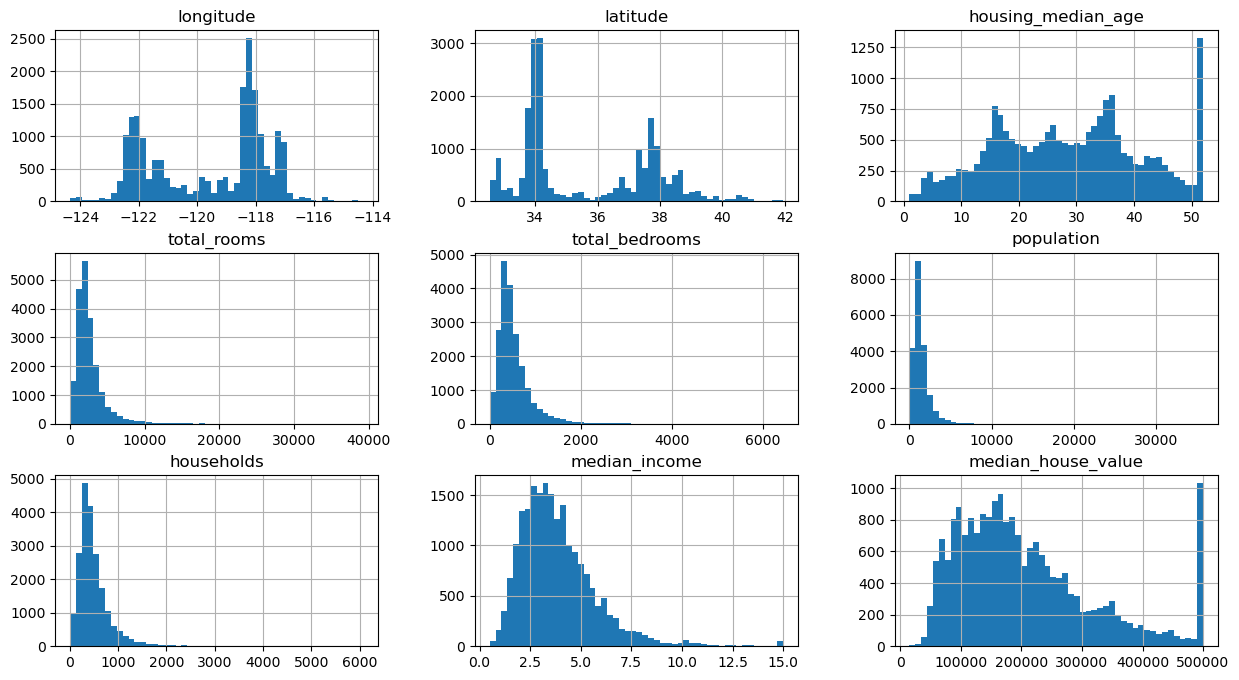

In [42]:
df.hist(figsize=(15, 8), bins=50)
plt.show

### Observations from Histograms
- housing_median_age and median_house_value are capped
- total_rooms, population, households are right skewed
- median_income is the most normally distributed feature

<function matplotlib.pyplot.show(close=None, block=None)>

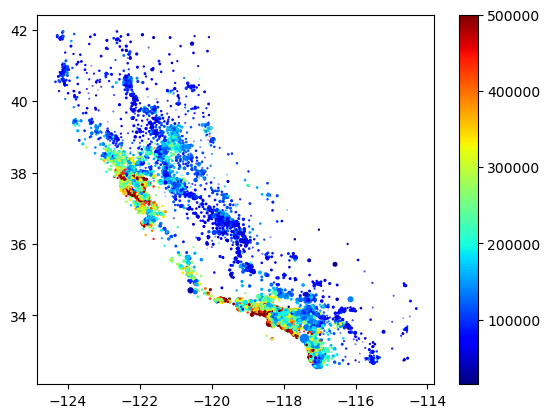

In [59]:
plt.scatter(x=df['longitude'], y=df['latitude'], s=df['population']/1000, c=df['median_house_value'], alpha=1, cmap='jet')
plt.colorbar()
plt.show

### Observations from Geographical Plot
- Coastal areas (Bay Area, LA) have highest house prices
- Inland areas are significantly cheaper
- High population districts also tend to have higher prices
- Location is clearly a strong predictor of house value

In [70]:
df.corr

<bound method DataFrame.corr of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  

<function matplotlib.pyplot.show(close=None, block=None)>

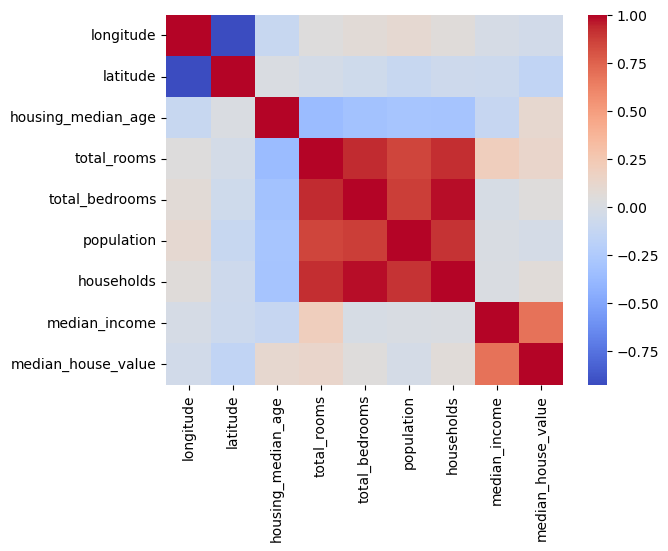

In [79]:
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show

### Observations from Correlation Heatmap
- median_income is strongest predictor of median_house_value (0.69)
- housing_median_age has weak correlation with median_house_value
- latitude and longitude are negatively correlated with median_house_value
- total_rooms, total_bedrooms, population, households are highly 
  correlated with each other → multicollinearity